---
title: 'Classification and Logistic Regression'
---

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [46]:
import kagglehub
data_path = kagglehub.dataset_download('harsh812saini/heart-disease-prediction-dataset')
df = pd.read_csv(data_path + '/Dataset.csv')
print(df.keys())
gender = df['gender']
male = gender == 'Male'
female = ~male
age = np.array(df['age'][male])
age = (age - np.mean(age)) / np.std(age)
bmi = np.array(df['BMI'][male])
chol = np.array(df['cholesterol (mg/dl)'][male])
chol = (chol - np.mean(chol)) / np.std(chol)
systolic_bp = np.array(df['systolic B.P.(mm_hg)'][male])
systolic_bp = (systolic_bp - np.mean(systolic_bp)) / np.std(systolic_bp)
diastolic_bp = np.array(df['diastolic B.P.(mm_hg)'][male])
outcomes = np.array(df['Resting ECG Result'][male])

Index(['patient_id', 'age', 'gender', 'cholesterol (mg/dl)', 'BMI',
       'Heart Rate', 'Glucose (mg/dl)', 'systolic B.P.(mm_hg)',
       'diastolic B.P.(mm_hg)', 'Resting ECG Result', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18'],
      dtype='str')


It is pretty typical that given some data set, say $\left\{{\bf x}_{j}\right\}_{j=1}^{N_{D}}$ that we might want to *classify* or *label* the data.  The simplest example of this would be sorting the data into two distinct bins, numerically denoted by a variable $y\in\left\{0,1\right\}$.  This lets us say whether something is a species of flower or not, dog or cat, true or false.  Whatever *property*/*not-property* dichotomy that matters to you can be framed this way.  While this kind of question is pretty natural, that we frame everything in probabilistic terms from here on out is maybe not as obvious.  The point though is that we only imagine that a machine is capable of learning class distinction via probability, i.e., it is very likely that a cat is not a dog is something we think a computer can manage.  Maybe that is also how our brains work, but who knows (we really don't).

Let's look at this using the imported data from above.  Our ${\bf x}$ consists of, controlling for men, the various measurements

$$
{\bf x} = \left(\text{age},\text{systolic bp},\text{cholesterol} \right)
$$

For outcomes, the data measures 'Resting ECG Result' which takes on the values 'Normal sinus rhythm', 'Sinus bradycardia', 'Atrial Fibrilation', and several other negative health outcomes.  Thus, we can go back and label the data with outcome $y=1$ is they have 'Normal sinus rhythm' and $y=0$ otherwise.   

We can look at corresponding scatter plots with outcome labels across dimensions.

In [47]:
y = np.zeros(len(age))
healthy = outcomes == 'Normal sinus rhythm'
unhealthy = ~healthy
y[healthy] = 1

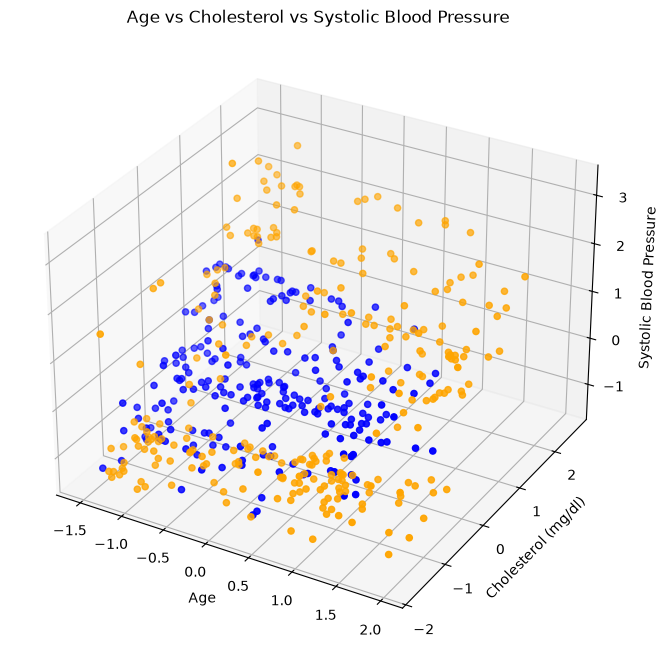

In [49]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

ax.scatter(age[healthy], chol[healthy], systolic_bp[healthy], c='b')
ax.scatter(age[unhealthy], chol[unhealthy], systolic_bp[unhealthy], c='orange')
ax.set_xlabel('Age')
ax.set_ylabel('Cholesterol (mg/dl)')
ax.set_zlabel('Systolic Blood Pressure')
ax.set_title('Age vs Cholesterol vs Systolic Blood Pressure')

plt.show()

Text(0.5, 1.0, 'Age vs Systolic Blood Pressure')

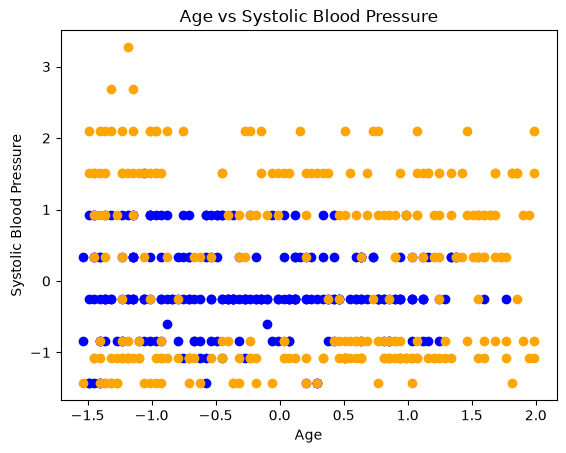

In [50]:
plt.scatter(age[healthy], systolic_bp[healthy], c='b')
plt.scatter(age[unhealthy], systolic_bp[unhealthy], c='orange')
plt.xlabel('Age')
plt.ylabel('Systolic Blood Pressure')
plt.title('Age vs Systolic Blood Pressure')

Text(0.5, 1.0, 'Systolic Blood Pressure vs Cholesterol (mg/dl)')

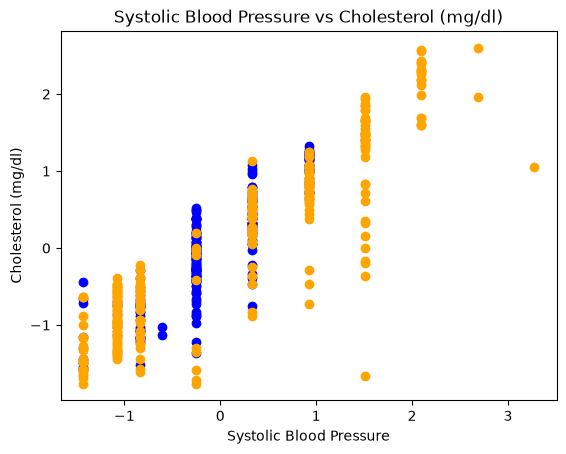

In [51]:
plt.scatter(systolic_bp[healthy], chol[healthy], c='b')
plt.scatter(systolic_bp[unhealthy], chol[unhealthy], c='orange')
plt.xlabel('Systolic Blood Pressure')
plt.ylabel('Cholesterol (mg/dl)')
plt.title('Systolic Blood Pressure vs Cholesterol (mg/dl)')

So, the go-to probabilistic model for a two-state random variable $Y$ is the *Bernoulli*-distribution.  Introducing the parameter $\theta$ where $0<\theta<1$, if we say $Y \sim \text{Ber}(\theta)$ then 

$$
\mathbb{P}(Y=1) = \theta, ~\mathbb{P}(Y=0) = 1-\theta.
$$

This has a corresponding distribution funciton $\text{ber}(y|\theta)=\theta^{y}(1-\theta)^{1-y}$.

*Problem*: Show that $\sum_{y=0}^{1}\text{ber}(y|\theta)=1$.

*Problem*: Show that $\mathbb{E}[Y]=\theta$.  

Not too bad; certainly easier than messing with Gaussians.  But now we want to ask a more challening question.  Suppose I give you labeled training data $\left\{({\bf x}_{j}, y_{j})\right\}_{j=1}^{N_{D}}$.  Now, I want you to model this data via a probability distribution 

$$
p(y|{\bf x},{\bf w},b) = \text{ber}(y|\sigma(\left<{\bf w},{\bf x}\right>+b)), ~ \sigma(x) = \frac{1}{1+e^{-x}}.
$$

Here, the *sigmoid* function $\sigma(x)$ is introduced.  

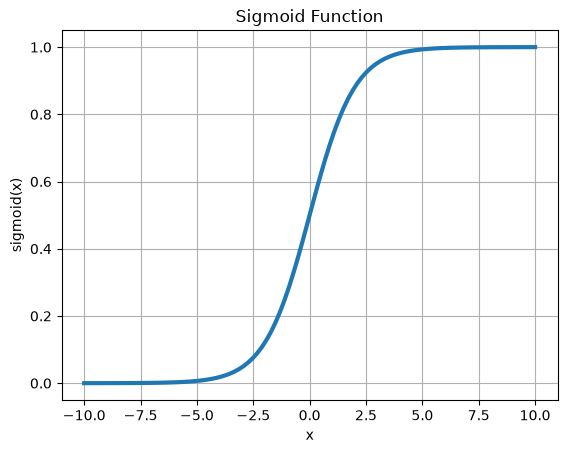

In [7]:
# Plot of the Sigmoid

sigmoid = lambda x: 1 / (1 + np.exp(-x))
x = np.linspace(-10, 10, 100)
plt.plot(x, sigmoid(x),lw=3)
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.title('Sigmoid Function')
plt.grid(True)
plt.show()

So what's going on here?  As we see, the sigmoid $\sigma(x)$ is transforming $\left<{\bf w},{\bf x}\right>+b$ into something between 0 and 1 and thus something that can serve as an approximation to the average.  Noting that $\sigma(0)=1/2$, we see then that the corresponding (hyper)plane

$$
\left<{\bf w},{\bf x}\right>+b = 0
$$

gives us the surface over which we have exactly even odds of $y$ being $0$ or $1$.  Those points ${\bf x}$ such that $\left<{\bf w},{\bf x}\right>+b > 0$ are more likely to correspond to $y=1$ and vice versa.  Thus we call our plane $\left<{\bf w},{\bf x}\right>+b = 0$ a *decision boundary*.  

So with that bit of setup, we now need to figure out how to take training data and find ${\bf w}$ and $b$.  Again, we use a Maximum Likelihood Estimation (MLE) approach by introducing the log-likelihood function $\mathcal{L}({\bf w},b)$ where 

\begin{align*}
\mathcal{L}({\bf w},b) = & \sum_{j=1}^{N_{D}}\log \left(\text{ber}\left(y_{j}|\sigma\left(\left<{\bf w},{\bf x}_{j}\right>+b\right)\right)\right)\\
= & \sum_{j=1}^{N_{D}}y_{j}\log \left(\sigma\left(\left<{\bf w},{\bf x}_{j}\right>+b\right)\right) + (1-y_{j})\log \left(1-\sigma(\left<{\bf w},{\bf x}_{j}\right>+b)\right)
\end{align*}

*Problem*: From the above, show that 

$$
\mathcal{L}({\bf w},b) = -\sum_{j=1}^{N_{D}}(1-y_{j}) \left(\left<{\bf w},{\bf x}_{j}\right>+b\right) + \log\left(1+e^{- \left(\left<{\bf w},{\bf x}_{j}\right>+b\right)}\right)
$$

*Problem*: Show that 

$$
\nabla_{{\bf w}}\mathcal{L} = \sum_{j=1}^{N_{D}}{\bf x}_{j}\left(y_{j} - \sigma\left(\left<{\bf w},{\bf x}_{j}\right>+b\right)\right)
$$

and

$$
\frac{\partial \mathcal{L}}{\partial b} = \sum_{j=1}^{N_{D}}\left(y_{j} - \sigma\left(\left<{\bf w},{\bf x}_{j}\right>+b\right)\right).
$$

So, clearly trying to set these equal to zero and solving is not really going to work.  Thus, we need another method for finding the optimal choices $({\bf w}_{\ast},b_{\ast})$ so that 

\begin{align*}
({\bf w}_{\ast},b_{\ast}) = & \text{arg max}_{({\bf w},b)}\mathcal{L}({\bf w},b)\\
= & \text{arg min}_{({\bf w},b)}\left(-\mathcal{L}({\bf w},b)\right)
\end{align*}

In code, we would put this altogether in the following way.  

In [8]:
def log_likelihood_and_grad(y, X, w, beta):
    hplane = X.T @ w + beta * np.ones_like(y)
    sig = 1. / (1. + np.exp(-hplane))
    log_likelihood = -np.dot(1.-y, hplane) + np.sum(np.log(sig))
    grad_w = np.sum(X @ np.diag(y - sig), axis=1)
    grad_beta = np.sum(y - sig)
    return -log_likelihood, (-grad_w, -grad_beta)


### Optimization through Steepest Descent

If we let $\tilde{\mathcal{L}}({\bf w},b)=-\mathcal{L}({\bf w},b)$ then we are looking for minima.  Recalling vector Calculus, we know that the direction of *steepest descent* for a function is the negative of its gradient.  Thus, if we start at some parameter value $({\bf w}_{0},b_{0})$, then if we defined $({\bf w}_{1},b_{1})$ so that 

$$
({\bf w}_{1},b_{1}) = ({\bf w}_{0},b_{0}) - \gamma_{0} \nabla \tilde{\mathcal{L}}({\bf w}_{0},b_{0}), ~ \gamma_{0} > 0,
$$

then we would select $\gamma_{0}$ to be as large as possible so that 

$$
\tilde{\mathcal{L}}({\bf w}_{1},b_{1}) < \tilde{\mathcal{L}}({\bf w}_{0},b_{0}).
$$

As you might imagine, getting this to work can require a bit of trial and error.  Likewise, as we iterate, we see that *step sizes* $\gamma_{j}$ will have to vary in order to have the algorithm function efficiently.  Chosen to be too small, and the algorithm converges slowly.  Taken too large, and we might miss global minima when working on complex optimizaiton landscapes.  Choosing step size in gradient descent becomes a subject essentialy unto itself and gives rise to a slew of concepts such as *momentum*. 

This shows up by fixing $\gamma>0$ but then introducing a new positive momentum parameter $0<a<1$ so that we descend according to the scheme

\begin{align*}
\delta ({\bf w}, b)_{j} = & a~\delta ({\bf w},b)_{j-1} - \gamma \nabla_{({\bf w},b)} \tilde{\mathcal{L}}_{j-1}\\
({\bf w}, b)_{j} = & ({\bf w}, b)_{j-1} + \delta ({\bf w}, b)_{j}  
\end{align*}

*Problem*: If $\nabla_{({\bf w},b)}\tilde{\mathcal{L}}_{j} = {\bf c}$, show that 

$$
\delta ({\bf w}, b)_{j} = -\frac{\gamma}{1-a}{\bf c}
$$

So, momentum adapts step sizes to expand when the gradient $\nabla_{({\bf w},b)}\tilde{\mathcal{L}}_{j}$ does not change significantly and otherwise works by stepping per the size of $\gamma$.  Thus, we can choose small values of $\gamma$ and allow the method to adapt when reasonable to a much larger step size when favorable conditions appear.  In code we get:

In [9]:
def steepest_descent_with_momentum(y, X, a, gamma, tol):
    w = np.zeros(X.shape[0])
    beta = 0.
    d_w = np.zeros_like(w)
    d_beta = 0
    log_likelihood, (grad_w, grad_beta) = log_likelihood_and_grad(y, X, w, beta)
    grad_norm = np.sqrt(np.linalg.norm(grad_w)**2. + grad_beta**2.)
    print(f"Initial log likelihood: {log_likelihood}")
    print(f"Initial gradient norm: {grad_norm}")
    while grad_norm > tol:
        log_likelihood, (grad_w, grad_beta) = log_likelihood_and_grad(y, X, w, beta)
        grad_norm = np.sqrt(np.linalg.norm(grad_w)**2. + grad_beta**2.)
        d_w = a * d_w - gamma * grad_w
        d_beta = a * d_beta - gamma * grad_beta
        w += d_w
        beta += d_beta
        #print(f"Log likelihood: {log_likelihood}")
        #print(f"Gradient norm: {grad_norm}")
    print(f"Final log likelihood: {log_likelihood}")
    print(f"Final gradient norm: {grad_norm}")
    return w, beta

Putting everything together then, let's select a training data set from 90% of the data and then test our predictions on the remaining chunk of testing data.  

In [36]:
percentage_training = .9
num_men = age.size 
num_train_data = int(np.floor(percentage_training * num_men))
train_indices = np.sort(np.random.choice(np.arange(num_men), num_train_data, replace=False))
test_indices = np.setdiff1d(np.arange(num_men), train_indices)

Xtrain = np.zeros((3, num_train_data))
Xtrain[0, :] = age[train_indices]
Xtrain[1, :] = systolic_bp[train_indices]
Xtrain[2, :] = chol[train_indices]
ytrain = y[train_indices]

Xtest = np.zeros((3, num_men-num_train_data))
Xtest[0, :] = age[test_indices]
Xtest[1, :] = systolic_bp[test_indices]
Xtest[2, :] = chol[test_indices]
ytest = y[test_indices]

# fit to training data 
w, beta = steepest_descent_with_momentum(ytrain, Xtrain, 0.99, 1e-3, 1e-14)
print(w, beta)


Initial log likelihood: 311.9162312519754
Initial gradient norm: 56.776785896415866
Final log likelihood: 295.1875559456572
Final gradient norm: 7.53644380168212e-15
[-0.42347001 -0.70735865  0.50397918] -0.15201787648079054


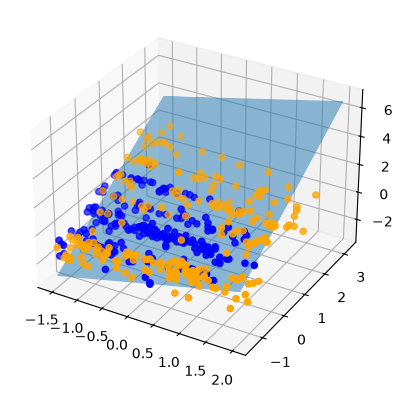

In [52]:
xmesh, ymesh = np.meshgrid(np.linspace(Xtrain[0, :].min(), Xtrain[0, :].max(), 100),
                                   np.linspace(Xtrain[1, :].min(), Xtrain[1, :].max(), 100))

zz = -1./w[2]*( beta * np.ones_like(xmesh) + w[0] * xmesh + w[1] * ymesh)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
healthy_train_men = ytrain == 1
unhealthy_train_men = ytrain == 0
ax.scatter(Xtrain[0, healthy_train_men], Xtrain[1, healthy_train_men], Xtrain[2, healthy_train_men], c='blue')
ax.scatter(Xtrain[0, unhealthy_train_men], Xtrain[1, unhealthy_train_men], Xtrain[2, unhealthy_train_men], c='orange')
ax.plot3D(xmesh, ymesh, zz, alpha=0.5)

To test, we now need to compare outcome probabilities with known labels.

In [38]:
test_hyperplane = Xtest.T @ w + beta * np.ones_like(ytest)
test_sig = 1 / (1 + np.exp(-test_hyperplane))
predictions = np.zeros_like(ytest)
healthy_prediction = test_sig >= 0.5
predictions[healthy_prediction] = 1

To quantify the performance of the logistic regression model, we introduce the idea of a *confusion matrix*, say ${\bf C}$ that ultimately quantifies $p(y|\hat{y})$ (we can do other metrics if we like; see Ch. 5 of the text).  We define ${\bf C}$ so that 

$$
{\bf C} = \begin{pmatrix} \frac{\text{TN}}{\text{FN}+\text{TN}} & \frac{\text{FP}}{\text{FP}+\text{TP}} \\  \frac{\text{FN}}{\text{FN}+\text{TN}} & \frac{\text{TP}}{\text{FP}+\text{TP}} \end{pmatrix}
$$

where TN denotes 'true negatives', FN 'false negatives, TP 'true positives', and FP 'false positives'.  These are computed in code as follows. 

In [39]:
true_negatives = np.sum((predictions == 0) & (ytest == 0))
false_positives = np.sum((predictions == 1) & (ytest == 0))
false_negatives = np.sum((predictions == 0) & (ytest == 1))
true_positives = np.sum((predictions == 1) & (ytest == 1))

c11 = true_negatives/np.sum(predictions == 0)
c12 = false_positives/np.sum(predictions == 1)
c21 = false_negatives/np.sum(predictions == 0)
c22 = true_positives/np.sum(predictions == 1)

class_confusion_matrix = np.array([[c11, c12], [c21, c22]])

print(class_confusion_matrix)

[[0.85714286 0.40909091]
 [0.14285714 0.59090909]]
